# 05 - Come si comporta il modello (analisi per la dashboard)

Modello scelto: **XGBoost con MSE asimmetrica `penalty=5`**, architettura tunata nella Sezione 9
di `01_eda.ipynb`. MAE 10.00 giorni, 4.4% di previsioni anticipate sul test.

Qui non si cerca piu' di migliorarlo: si guarda **come si comporta**, per sapere cosa mostrare
nella dashboard Streamlit e cosa invece va segnalato come inaffidabile.

La slide 13 chiede tre pannelli: **metriche del modello**, **feature importance**,
**simulazione su un caso**. Questo notebook prepara il materiale per tutti e tre, piu' la
risposta alla domanda da portare in plenaria (slide 10):

> *di quanti giorni si puo' accorciare la promessa senza superare il 5% di ritardi?*

**Nota sul vocabolario.** Il modello prevede *giorni di consegna*; il cliente vede una *data
promessa*. Una previsione **anticipata** (il modello dice meno giorni di quelli reali) diventa
una **consegna in ritardo** rispetto alla promessa. Sono la stessa cosa vista dai due lati:
la quota di anticipi del modello *e'* la quota di ritardi che il cliente subirebbe.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

from src import features

pd.set_option('display.max_columns', 50)
pd.options.display.float_format = '{:,.2f}'.format

## 1. Il modello, ricostruito identico

Stesse feature, stesso split, stessa architettura e stessa penalita' della Sezione 9. Il modello
viene allenato sul `fit` (85% del train) esattamente come quando abbiamo misurato 10.00gg / 4.4%:
riaddestrarlo su piu' dati cambierebbe le metriche che poi mostriamo in dashboard.

In [2]:
TOP_FEATURES = ['distance_km_mean', 'total_freight', 'distance_km_max',
                'customer_state', 'approval_hours', 'total_weight_g', 'main_category']
CAT_FEATURES = ['customer_state', 'main_category']
ARCH = dict(subsample=0.7, n_estimators=300, min_child_weight=3, max_depth=5,
            learning_rate=0.013707256063767185, colsample_bytree=0.6)
PENALTY = 5.0

ft = features.build_feature_table()
keep = ['order_id', 'purchase_date', 'delivery_days', 'estimated_days'] + TOP_FEATURES
df = ft[keep].copy()
for c in CAT_FEATURES:
    df[c] = df[c].astype('category')
df = df.sort_values('purchase_date').reset_index(drop=True)

split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:].copy()
fit_split = int(len(train) * 0.85)
fit_df, calib_df = train.iloc[:fit_split], train.iloc[fit_split:]


def asymmetric_mse(y_true, y_pred):
    residual = y_pred - y_true
    weight = np.where(residual < 0, PENALTY, 1.0)
    return 2 * weight * residual, 2 * weight


model = XGBRegressor(objective=asymmetric_mse, enable_categorical=True,
                     tree_method='hist', random_state=42, **ARCH)
model.fit(fit_df[TOP_FEATURES], fit_df['delivery_days'])

test['pred'] = model.predict(test[TOP_FEATURES])
test['err'] = test['pred'] - test['delivery_days']
test['abs_err'] = test['err'].abs()
test['err_baseline'] = test['estimated_days'] - test['delivery_days']

MAE = test['abs_err'].mean()
EARLY = (test['err'] < 0).mean()
print(f'fit {len(fit_df):,} | calib {len(calib_df):,} | test {len(test):,}')
print(f'periodo test: {test["purchase_date"].min()} -> {test["purchase_date"].max()}')
print(f'\nModello  : MAE {MAE:.2f} gg | anticipi {EARLY:.1%}')
print(f'Baseline : MAE {test["err_baseline"].abs().mean():.2f} gg | '
      f'anticipi {(test["err_baseline"] < 0).mean():.1%}')

fit 65,599 | calib 11,577 | test 19,294
periodo test: 2018-05-26 -> 2018-08-29

Modello  : MAE 10.00 gg | anticipi 4.4%
Baseline : MAE 13.13 gg | anticipi 5.3%


## 2. Il caso normale: come si distribuisce l'errore

Il MAE e' una media e nasconde la forma. Per la dashboard serve sapere quanto e' *tipico* un
errore, non solo quanto vale in media.

In [3]:
righe = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
riepilogo = pd.DataFrame({
    'errore modello (gg)': test['err'].quantile(righe).values,
    'errore baseline (gg)': test['err_baseline'].quantile(righe).values,
}, index=[f'p{int(q * 100)}' for q in righe])
print(riepilogo.round(1))

print()
for soglia in (1, 2, 3, 5, 7, 10):
    print(f'errore entro +/-{soglia:2d} gg :  modello {(test["abs_err"] <= soglia).mean():5.1%}'
          f'   baseline {(test["err_baseline"].abs() <= soglia).mean():5.1%}')

print(f'\nPrevisioni che sovrastimano (errore > 0): {(test["err"] > 0).mean():.1%}')

     errore modello (gg)  errore baseline (gg)
p1                 -8.20                 -7.70
p5                  0.50                 -0.50
p25                 6.20                  6.10
p50                 9.60                 12.00
p75                12.90                 19.10
p95                18.60                 29.50
p99                21.90                 37.50

errore entro +/- 1 gg :  modello  2.0%   baseline  4.2%
errore entro +/- 2 gg :  modello  4.5%   baseline  7.7%
errore entro +/- 3 gg :  modello  7.4%   baseline 10.8%
errore entro +/- 5 gg :  modello 16.3%   baseline 17.8%
errore entro +/- 7 gg :  modello 29.3%   baseline 29.0%
errore entro +/-10 gg :  modello 52.4%   baseline 42.2%

Previsioni che sovrastimano (errore > 0): 95.6%


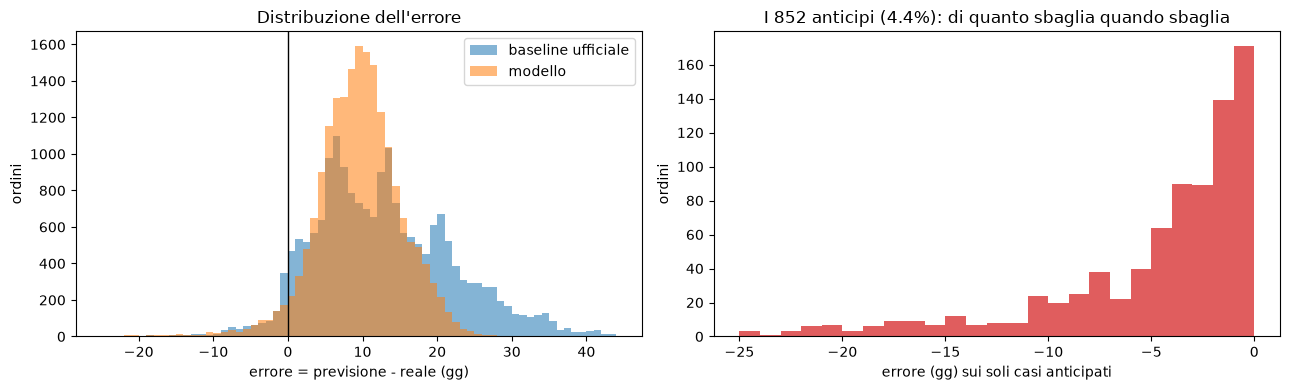

Gravita' degli anticipi (ritardo che subirebbe il cliente):
  mediana      : 3.3 gg
  media        : 6.4 gg
  90esimo perc.: 16.2 gg
  peggiore     : 113.8 gg

  ordini in ritardo di oltre 1 gg: 3.53%
  ordini in ritardo di oltre 2 gg: 2.81%
  ordini in ritardo di oltre 3 gg: 2.35%
  ordini in ritardo di oltre 5 gg: 1.55%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.arange(-25, 45, 1)
axes[0].hist(test['err_baseline'], bins=bins, alpha=0.55, label='baseline ufficiale')
axes[0].hist(test['err'], bins=bins, alpha=0.55, label='modello')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('errore = previsione - reale (gg)')
axes[0].set_ylabel('ordini')
axes[0].set_title('Distribuzione dell\'errore')
axes[0].legend()

early = test.loc[test['err'] < 0, 'err']
axes[1].hist(early, bins=np.arange(-25, 1, 1), color='tab:red', alpha=0.75)
axes[1].set_xlabel('errore (gg) sui soli casi anticipati')
axes[1].set_ylabel('ordini')
axes[1].set_title(f'I {len(early):,} anticipi ({EARLY:.1%}): di quanto sbaglia quando sbaglia')
fig.tight_layout()
plt.show()

print('Gravita\' degli anticipi (ritardo che subirebbe il cliente):')
print(f'  mediana      : {-early.median():.1f} gg')
print(f'  media        : {-early.mean():.1f} gg')
print(f'  90esimo perc.: {-early.quantile(0.10):.1f} gg')
print(f'  peggiore     : {-early.min():.1f} gg')
print()
for soglia in (1, 2, 3, 5):
    print(f'  ordini in ritardo di oltre {soglia} gg: {(test["err"] < -soglia).mean():.2%}')

### Cosa dice la distribuzione

Tre fatti che vanno detti in dashboard, perche' cambiano l'interpretazione del "MAE 10 giorni":

1. **Il modello non e' piu' preciso della baseline: e' piu' prudente in modo controllato.**
   Entro +/-3 giorni ci finisce il **7.4%** degli ordini contro il **10.8%** della baseline.
   Il modello vince solo allargando la finestra: entro +/-10 giorni sta al **52.4%** contro il
   **42.2%**. Tradotto: taglia le sovrastime assurde (p99 passa da +37.5 a +21.9 giorni) ma non
   promette date "giuste al giorno".
2. **Il MAE qui e' quasi tutto sovrastima, per costruzione.** Il 95.6% delle previsioni e' sopra
   il valore reale e l'errore mediano e' **+9.6 giorni**. Con `penalty=5` il modello non stima il
   giorno tipico: stima un livello prudente (in gergo, un *expectile* all'83%). Un MAE di 10
   giorni qui **non** significa "sbaglia di 10 giorni in un senso o nell'altro".
3. **Quando sbaglia in ritardo, di solito sbaglia di poco.** Degli anticipi, la mediana e' 3.3
   giorni. Gli ordini in ritardo di piu' di 5 giorni sono l'**1.55%** del totale. La coda esiste
   (il caso peggiore e' -113.8 giorni) ma e' rarissima.

## 3. Dove funziona e dove no: il comportamento per segmento

Questa e' la tabella che in dashboard diventa il pannello "affidabilita' per segmento": dice a chi
guarda se la previsione che sta leggendo appartiene a una zona solida o a una zona fragile.

In [5]:
def profilo(gruppi, nome):
    g = test.groupby(gruppi, observed=True)
    out = pd.DataFrame({
        'n_ordini': g.size(),
        'MAE': g['abs_err'].mean(),
        'anticipi_%': g.apply(lambda d: (d['err'] < 0).mean() * 100, include_groups=False),
        'errore_medio': g['err'].mean(),
    })
    out.index.name = nome
    return out


test['fascia_distanza'] = pd.cut(test['distance_km_mean'],
                                 [-1, 50, 200, 500, 1000, 2000, np.inf],
                                 labels=['<50km', '50-200', '200-500', '500-1000', '1000-2000', '>2000km'])
test['fascia_peso'] = pd.cut(test['total_weight_g'], [-1, 500, 2000, 10000, np.inf],
                             labels=['<0.5kg', '0.5-2kg', '2-10kg', '>10kg'])

print('--- per distanza venditore-cliente ---')
display(profilo('fascia_distanza', 'distanza').round(2))
print('--- per peso totale ---')
display(profilo('fascia_peso', 'peso').round(2))

--- per distanza venditore-cliente ---


,n_ordini,MAE,anticipi_%,errore_medio
distanza,,,,
<50km,2887,5.71,8.52,4.83
50-200,2842,6.83,5.77,6.29
200-500,5853,10.56,2.65,10.22
500-1000,4703,11.65,2.98,11.16
1000-2000,1864,12.72,4.72,11.87
>2000km,1067,14.79,4.87,14.01


--- per peso totale ---


,n_ordini,MAE,anticipi_%,errore_medio
peso,,,,
<0.5kg,8363,9.50,4.85,8.93
0.5-2kg,6602,10.15,3.91,9.67
2-10kg,3471,10.68,3.72,10.08
>10kg,858,10.85,6.88,9.86


In [6]:
print('--- per stato del cliente (i 12 piu\' frequenti nel test) ---')
top_stati = test['customer_state'].value_counts().head(12).index
display(profilo('customer_state', 'stato').loc[top_stati].round(2))

print('--- per categoria prodotto (le 10 piu\' frequenti) ---')
top_cat = test['main_category'].value_counts().head(10).index
display(profilo('main_category', 'categoria').loc[top_cat].round(2))

--- per stato del cliente (i 12 piu' frequenti nel test) ---


,n_ordini,MAE,anticipi_%,errore_medio
customer_state,,,,
SP,8922,7.45,5.44,6.89
RJ,2211,14.72,2.89,14.27
MG,2133,10.00,2.67,9.59
PR,978,9.50,3.07,9.21
RS,938,11.81,3.09,11.25
BA,639,13.06,7.98,11.50
SC,619,12.15,1.78,11.93
DF,468,10.53,4.06,9.91
ES,360,11.32,5.00,10.36


--- per categoria prodotto (le 10 piu' frequenti) ---


,n_ordini,MAE,anticipi_%,errore_medio
main_category,,,,
health_beauty,2302,9.64,5.78,8.99
bed_bath_table,1784,10.93,2.02,10.54
housewares,1517,9.69,3.56,9.24
watches_gifts,1381,10.18,5.87,9.29
sports_leisure,1253,9.94,3.19,9.52
computers_accessories,1143,10.12,4.64,9.48
furniture_decor,1015,10.69,3.55,10.11
auto,955,10.98,3.04,10.49
telephony,672,9.35,5.80,8.69


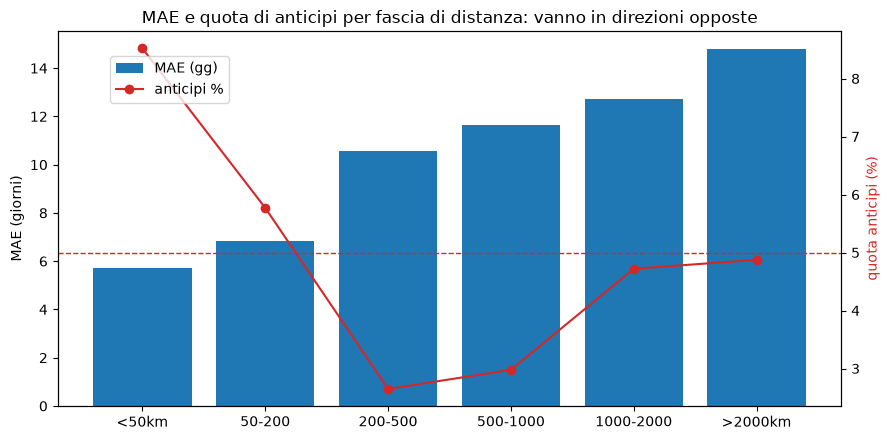

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
per_dist = profilo('fascia_distanza', 'distanza')
x = np.arange(len(per_dist))
ax.bar(x, per_dist['MAE'], color='tab:blue', label='MAE (gg)')
ax.set_xticks(x)
ax.set_xticklabels(per_dist.index)
ax.set_ylabel('MAE (giorni)')
ax2 = ax.twinx()
ax2.plot(x, per_dist['anticipi_%'], color='tab:red', marker='o', label='anticipi %')
ax2.axhline(5, color='tab:red', linestyle='--', linewidth=1)
ax2.set_ylabel('quota anticipi (%)', color='tab:red')
ax.set_title('MAE e quota di anticipi per fascia di distanza: vanno in direzioni opposte')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
fig.tight_layout()
plt.show()

### Il segmento a rischio non e' quello che ci si aspetta

**MAE e rischio di ritardo vanno in direzioni opposte.** Il MAE cresce con la distanza (da 5.71gg
sotto i 50km a 14.79gg sopra i 2000km), ma la quota di anticipi fa l'opposto: **8.52% sotto i
50km** contro il 2.65% nella fascia 200-500km.

Il motivo e' che sulle consegne vicine il margine di prudenza in giorni e' piccolo in valore
assoluto, quindi basta poco per bucarlo; sulle lunghe distanze il modello mette cosi' tanto
margine che il ritardo diventa raro (ma la promessa e' larga).

Conseguenza diretta per il business: **il 5% di ritardi e' sforato proprio dove il modello sembra
piu' preciso.** Segmenti sopra la soglia:

| segmento | anticipi | nota |
|---|---|---|
| distanza < 50km | 8.5% | il piu' critico per volume e rischio |
| peso > 10kg | 6.9% | 858 ordini |
| stato BA | 8.0% | |
| stato SP | 5.4% | pesa il 46% del test, quindi sposta la media |

All'opposto, RJ e CE hanno MAE altissimo (14.7 e 16.8 giorni) ma rischio di ritardo bassissimo
(2.9% e 1.4%): li' la promessa e' semplicemente troppo larga, e c'e' margine per accorciarla.

## 4. I casi strani

Quattro famiglie di stranezze che la dashboard deve saper gestire: dati mancanti, segmenti rari,
input estremi, e gli errori della coda.

In [8]:
print('--- 4a. Feature mancanti nel test ---')
mancanti = (test[TOP_FEATURES].isna().mean() * 100).round(2)
print(mancanti[mancanti > 0].to_string() if (mancanti > 0).any() else 'nessuna')

has_na = test[TOP_FEATURES].isna().any(axis=1)
conf = pd.DataFrame({
    'n_ordini': [has_na.sum(), (~has_na).sum()],
    'MAE': [test.loc[has_na, 'abs_err'].mean(), test.loc[~has_na, 'abs_err'].mean()],
    'anticipi_%': [(test.loc[has_na, 'err'] < 0).mean() * 100,
                    (test.loc[~has_na, 'err'] < 0).mean() * 100],
}, index=['con almeno un valore mancante', 'completi'])
display(conf.round(2))

--- 4a. Feature mancanti nel test ---
distance_km_mean   0.40
distance_km_max    0.40
main_category      0.53


,n_ordini,MAE,anticipi_%
con almeno un valore mancante,179,10.42,3.91
completi,19115,9.99,4.42


In [9]:
print('--- 4b. Segmenti rari: categorie poco viste in training ---')
freq_train = fit_df['main_category'].value_counts()
test['cat_rara'] = test['main_category'].map(freq_train).fillna(0) < 100

rare = pd.DataFrame({
    'n_ordini': [test['cat_rara'].sum(), (~test['cat_rara']).sum()],
    'MAE': [test.loc[test['cat_rara'], 'abs_err'].mean(), test.loc[~test['cat_rara'], 'abs_err'].mean()],
    'anticipi_%': [(test.loc[test['cat_rara'], 'err'] < 0).mean() * 100,
                    (test.loc[~test['cat_rara'], 'err'] < 0).mean() * 100],
}, index=['categoria rara (<100 ordini in training)', 'categoria comune'])
display(rare.round(2))

mai_viste = set(test['main_category'].dropna().unique()) - set(freq_train[freq_train > 0].index)
print(f'categorie presenti nel test ma mai viste in training: {len(mai_viste)}')

--- 4b. Segmenti rari: categorie poco viste in training ---


,n_ordini,MAE,anticipi_%
categoria rara (<100 ordini in training),653,9.07,5.05
categoria comune,18641,10.03,4.39


categorie presenti nel test ma mai viste in training: 0


In [10]:
print('--- 4c. Input estremi (oltre il 99esimo percentile) ---')
righe_est = []
for nome, col in [('distanza', 'distance_km_mean'), ('peso', 'total_weight_g'),
                  ('spedizione', 'total_freight'), ('ore approvazione', 'approval_hours')]:
    mask = test[col] > test[col].quantile(0.99)
    righe_est.append(dict(caso=f'{nome} > p99', n_ordini=int(mask.sum()),
                          MAE=test.loc[mask, 'abs_err'].mean(),
                          anticipi_pct=(test.loc[mask, 'err'] < 0).mean() * 100,
                          previsione_media=test.loc[mask, 'pred'].mean()))
righe_est.append(dict(caso='-- tutto il test --', n_ordini=len(test), MAE=MAE,
                      anticipi_pct=EARLY * 100, previsione_media=test['pred'].mean()))
display(pd.DataFrame(righe_est).set_index('caso').round(2))

--- 4c. Input estremi (oltre il 99esimo percentile) ---


,n_ordini,MAE,anticipi_pct,previsione_media
caso,,,,
distanza > p99,193,14.91,4.15,31.28
peso > p99,193,11.20,9.33,20.71
spedizione > p99,193,13.50,5.18,25.97
ore approvazione > p99,193,10.83,2.59,21.01
-- tutto il test --,19294,10.00,4.42,18.19


In [11]:
print('--- 4d. La coda: i 12 errori peggiori ---')
display(test.nlargest(12, 'abs_err')[
    ['delivery_days', 'estimated_days', 'pred', 'err', 'distance_km_mean',
     'total_weight_g', 'customer_state', 'main_category']].round(1))

coda = test[test['abs_err'] > 20]
sovra, anticipi_coda = coda[coda['err'] > 0], coda[coda['err'] < 0]
print(f'\nErrori estremi (|errore| > 20gg): {len(coda):,} ordini, {len(coda) / len(test):.1%} del test')
print(f'  sovrastime ({len(sovra)}): consegna reale mediana {sovra["delivery_days"].median():.0f}gg, '
      f'previsti {sovra["pred"].median():.0f}gg, distanza mediana {sovra["distance_km_mean"].median():.0f}km')
print(f'  anticipi   ({len(anticipi_coda)}): consegna reale mediana '
      f'{anticipi_coda["delivery_days"].median():.0f}gg, previsti {anticipi_coda["pred"].median():.0f}gg')

lente = test['delivery_days'] > 30
print(f'\nOrdini con consegna reale oltre 30 giorni: {lente.sum()} ({lente.mean():.2%} del test)')
print(f'  il modello li anticipa nel {(test.loc[lente, "err"] < 0).mean():.1%} dei casi')
print(f'  ma pesano solo il {test.loc[lente, "abs_err"].sum() / test["abs_err"].sum():.1%} del MAE totale')

--- 4d. La coda: i 12 errori peggiori ---


,delivery_days,estimated_days,pred,err,distance_km_mean,total_weight_g,customer_state,main_category
78171,136.80,40.20,23.00,-113.80,824.40,550.00,ES,bed_bath_table
82769,79.00,20.30,16.40,-62.60,490.90,"2,550.00",SP,cool_stuff
79585,69.10,10.60,10.80,-58.30,37.90,"1,450.00",SP,furniture_decor
85694,68.00,7.40,10.90,-57.10,28.30,"2,450.00",SP,auto
82072,76.00,32.30,25.80,-50.20,"1,346.80",383.00,BA,cool_stuff
86214,68.90,21.90,21.80,-47.10,844.00,450.00,RS,computers_accessories
87368,11.10,44.50,57.20,46.10,"3,312.40","1,850.00",RR,furniture_decor
77950,70.00,45.20,24.70,-45.20,"1,796.20","12,100.00",BA,computers
84353,77.70,27.10,32.70,-45.00,"2,274.70",900.00,AL,health_beauty
78582,11.00,28.10,55.00,44.00,88.00,"9,150.00",SP,home_construction



Errori estremi (|errore| > 20gg): 602 ordini, 3.1% del test
  sovrastime (541): consegna reale mediana 7gg, previsti 28gg, distanza mediana 935km
  anticipi   (61): consegna reale mediana 50gg, previsti 20gg

Ordini con consegna reale oltre 30 giorni: 183 (0.95% del test)
  il modello li anticipa nel 95.1% dei casi
  ma pesano solo il 1.6% del MAE totale


### Cosa abbiamo imparato dai casi strani

- **I dati mancanti non sono un problema.** Solo 179 ordini (0.9%) hanno una feature nulla e il
  modello li gestisce nativamente: MAE 10.42 contro 9.99, quota di anticipi perfino piu' bassa.
  In dashboard si puo' tranquillamente accettare un input incompleto.
- **Le categorie rare nemmeno.** 653 ordini in categorie viste meno di 100 volte in training
  hanno MAE 9.07, *migliore* della media. E nessuna categoria del test era sconosciuta al
  modello. Non serve un ramo di fallback.
- **Gli input estremi invece contano, e in modo asimmetrico.** Gli ordini molto pesanti (oltre il
  p99) hanno una quota di anticipi del **9.33%**, piu' del doppio della media: il modello li
  sottostima. Le distanze estreme invece alzano il MAE (14.91) ma non il rischio di ritardo.
- **La coda ha due nature diverse, e vanno raccontate separatamente.** Dei 602 ordini con errore
  oltre 20 giorni, il 90% sono **sovrastime** su consegne arrivate in 7 giorni mediani mentre il
  modello ne prevedeva 28 (distanza mediana 935km: e' il problema di taratura della Sezione 7).
  Il restante 10% sono **anticipi su consegne anomale**, con 50 giorni reali mediani: casi in cui
  qualcosa e' andato storto nella logistica, non errori del modello. Gli ordini oltre 30 giorni
  reali sono lo 0.95% del test, il modello li sbaglia quasi sempre (95%), ma pesano solo l'1.6%
  del MAE: **non vale la pena progettare il modello attorno a loro.**

## 5. Come reagisce agli input (materiale per il simulatore)

Il pannello "simulazione su un caso" fa muovere all'utente una feature alla volta. Perche' sia
credibile, la risposta del modello deve essere **monotona e leggibile**: se allontano il cliente
la previsione deve salire, non zigzagare.

Curva di sensitivita': si fissa il test set reale, si forza una feature su una griglia di valori e
si media la previsione. E' la partial dependence, calcolata a mano per evitare problemi fra
l'obiettivo custom e scikit-learn.

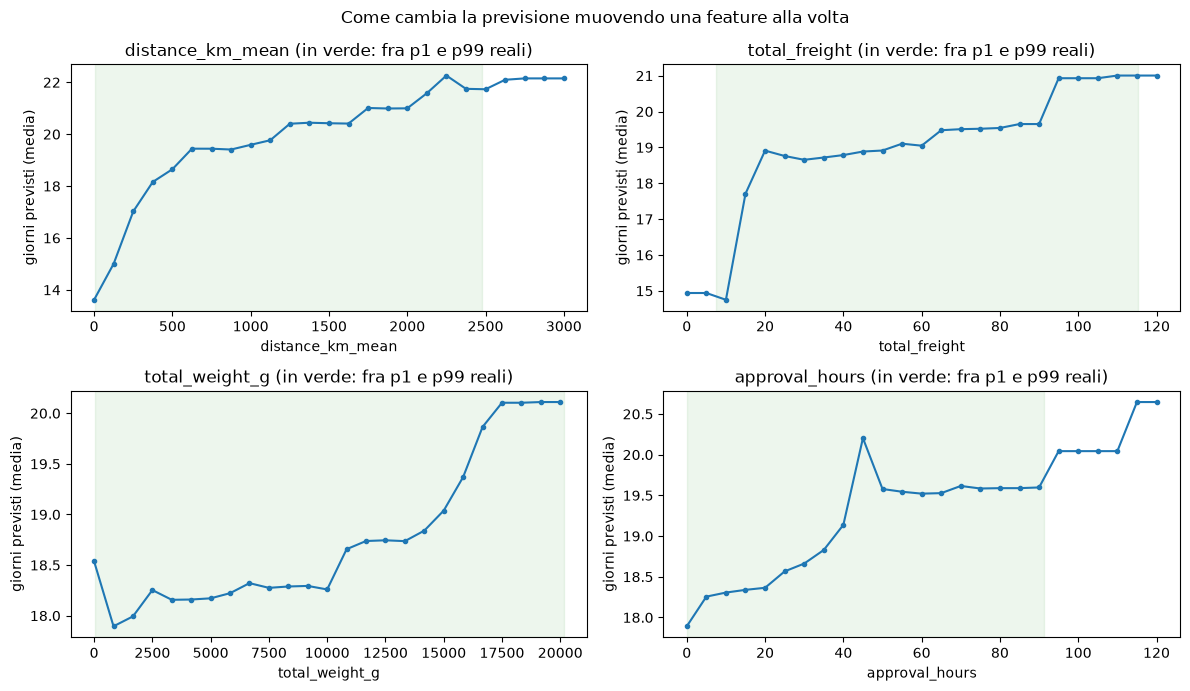

In [12]:
def sensitivita(feature, griglia, campione=3000):
    base = test.sample(min(campione, len(test)), random_state=42)[TOP_FEATURES].copy()
    return [model.predict(base.assign(**{feature: v})).mean() for v in griglia]


griglie = {
    'distance_km_mean': np.linspace(0, 3000, 25),
    'total_freight': np.linspace(0, 120, 25),
    'total_weight_g': np.linspace(0, 20000, 25),
    'approval_hours': np.linspace(0, 120, 25),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (feat, grid) in zip(axes.ravel(), griglie.items()):
    ax.plot(grid, sensitivita(feat, grid), marker='.')
    ax.set_xlabel(feat)
    ax.set_ylabel('giorni previsti (media)')
    p1, p99 = test[feat].quantile([0.01, 0.99])
    ax.axvspan(p1, p99, color='green', alpha=0.07)
    ax.set_title(f'{feat} (in verde: fra p1 e p99 reali)')
fig.suptitle('Come cambia la previsione muovendo una feature alla volta')
fig.tight_layout()
plt.show()

In [13]:
print('--- Intervalli consigliati per i controlli della dashboard ---')
num_features = [c for c in TOP_FEATURES if c not in CAT_FEATURES]
intervalli = test[num_features].quantile([0.01, 0.25, 0.50, 0.75, 0.99]).T
intervalli.columns = ['p1', 'p25', 'mediana', 'p75', 'p99']
display(intervalli.round(1))

print('Valori ammessi per le categoriche:')
print(f"  customer_state : {test['customer_state'].nunique()} stati")
print(f"  main_category  : {test['main_category'].nunique()} categorie")

--- Intervalli consigliati per i controlli della dashboard ---


,p1,p25,mediana,p75,p99
distance_km_mean,5.00,128.40,397.40,769.90,"2,479.10"
total_freight,7.40,13.90,18.60,25.80,115.40
distance_km_max,5.00,129.00,399.90,772.80,"2,479.50"
approval_hours,0.10,0.20,0.40,15.20,91.30
total_weight_g,50.00,300.00,650.00,"1,800.00","20,153.50"


Valori ammessi per le categoriche:
  customer_state : 27 stati
  main_category  : 68 categorie


## 6. La domanda per la plenaria

> *Di quanti giorni si puo' accorciare la promessa senza superare il 5% di ritardi?*

La risposta e' la differenza fra la promessa attuale (`estimated_days`) e quella del modello,
misurata sul test insieme alla quota di ritardi che ne deriverebbe.

Promessa attuale (baseline): 21.4 gg in media
Promessa col modello       : 18.2 gg in media

Giorni guadagnati: 3.2 in media, 1.7 mediana
Ordini in cui la promessa si accorcia: 58.7%

Quota di ritardi che ne deriva: 4.4% (contro 5.3% di oggi)


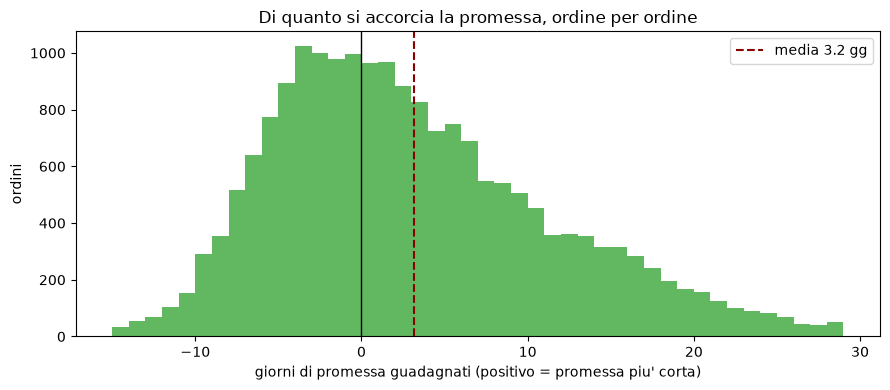

In [14]:
risparmio = test['estimated_days'] - test['pred']

print(f'Promessa attuale (baseline): {test["estimated_days"].mean():.1f} gg in media')
print(f'Promessa col modello       : {test["pred"].mean():.1f} gg in media')
print(f'\nGiorni guadagnati: {risparmio.mean():.1f} in media, {risparmio.median():.1f} mediana')
print(f'Ordini in cui la promessa si accorcia: {(risparmio > 0).mean():.1%}')
print(f'\nQuota di ritardi che ne deriva: {EARLY:.1%} '
      f'(contro {(test["err_baseline"] < 0).mean():.1%} di oggi)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(risparmio, bins=np.arange(-15, 30, 1), color='tab:green', alpha=0.75)
ax.axvline(0, color='black', linewidth=1)
ax.axvline(risparmio.mean(), color='darkred', linestyle='--',
           label=f'media {risparmio.mean():.1f} gg')
ax.set_xlabel('giorni di promessa guadagnati (positivo = promessa piu\' corta)')
ax.set_ylabel('ordini')
ax.set_title('Di quanto si accorcia la promessa, ordine per ordine')
ax.legend()
fig.tight_layout()
plt.show()

### La risposta, in una riga

**Si puo' accorciare la promessa di 3.2 giorni in media (1.7 mediani) abbassando allo stesso
tempo i ritardi dal 5.3% al 4.4%.** La promessa media passa da 21.4 a 18.2 giorni, e il 58.7%
degli ordini riceve una data piu' vicina.

Non e' un compromesso: si guadagna su entrambi i fronti, perche' la baseline attuale non e' solo
larga, e' larga *nel punto sbagliato* (concede tantissimo margine dove non serve e poco dove
servirebbe).

## 7. Feature importance (secondo pannello della slide 13)

Qui serve attenzione, perche' e' facilissimo pubblicare un grafico sbagliato.

Questo modello **non stima il giorno tipico**: con `penalty=5` stima un livello prudente
(un *expectile* all'83%). Misurare la permutation importance con il MAE darebbe importanze
negative su quasi tutte le feature, perche' il MAE premia la mediana e mescolare una feature che
alza le previsioni "migliora" il MAE peggiorando il modello. Usiamo quindi **la loss asimmetrica
stessa**, cioe' quella che il modello ottimizza davvero.

Confrontiamo tre viste: quanto il modello **usa** ogni feature (gain, in addestramento), e quanto
ogni feature **serve** su due periodi diversi (calibrazione, adiacente al training, e test, piu'
lontano nel tempo).

,utilita' su calib (apr-mag),utilita' su test (giu-ago),uso in training (gain)
customer_state,20.18,-4.62,"184,730.16"
distance_km_mean,17.79,-6.45,"95,167.41"
distance_km_max,-0.08,-7.90,"52,565.72"
total_freight,4.54,-4.29,"46,631.67"
main_category,2.79,0.83,"26,902.28"
approval_hours,0.99,0.70,"22,506.99"
total_weight_g,0.62,0.98,"15,602.93"


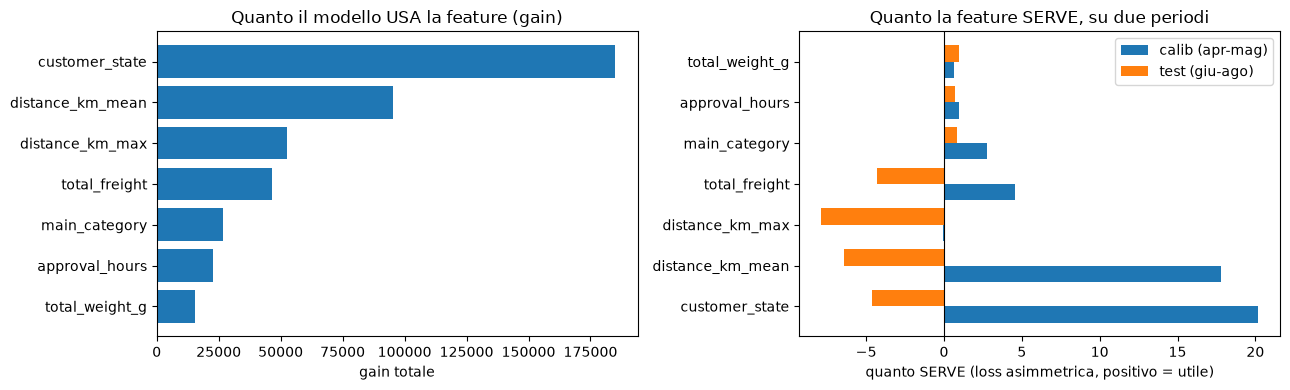

In [15]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer


def perdita_asimmetrica(y_true, y_pred):
    residual = np.asarray(y_pred) - np.asarray(y_true)
    weight = np.where(residual < 0, PENALTY, 1.0)
    return float(np.mean(weight * residual ** 2))


scorer = make_scorer(perdita_asimmetrica, greater_is_better=False)

viste = {}
for nome, parte in [('utilita\' su calib (apr-mag)', calib_df), ('utilita\' su test (giu-ago)', test)]:
    pi = permutation_importance(model, parte[TOP_FEATURES], parte['delivery_days'],
                                n_repeats=5, random_state=42, scoring=scorer)
    viste[nome] = pd.Series(pi.importances_mean, index=TOP_FEATURES)

gain = pd.Series(model.get_booster().get_score(importance_type='gain'))
viste['uso in training (gain)'] = gain

importanze = pd.DataFrame(viste).sort_values('uso in training (gain)', ascending=False)
display(importanze.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
g = importanze['uso in training (gain)'].sort_values()
axes[0].barh(g.index, g.values, color='tab:blue')
axes[0].set_title('Quanto il modello USA la feature (gain)')
axes[0].set_xlabel('gain totale')

conf_imp = importanze[["utilita' su calib (apr-mag)", "utilita' su test (giu-ago)"]]
y = np.arange(len(conf_imp))
axes[1].barh(y - 0.2, conf_imp.iloc[:, 0], 0.4, label='calib (apr-mag)')
axes[1].barh(y + 0.2, conf_imp.iloc[:, 1], 0.4, label='test (giu-ago)')
axes[1].set_yticks(y)
axes[1].set_yticklabels(conf_imp.index)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('quanto SERVE (loss asimmetrica, positivo = utile)')
axes[1].set_title('Quanto la feature SERVE, su due periodi')
axes[1].legend()
fig.tight_layout()
plt.show()

In [16]:
# Perche' la geografia "gira": errore medio per fascia di distanza nei due periodi.
confronto_periodi = []
for nome, parte in [('calib (apr-mag)', calib_df), ('test (giu-ago)', test)]:
    p = parte.copy()
    p['err'] = model.predict(p[TOP_FEATURES]) - p['delivery_days']
    p['fascia'] = pd.cut(p['distance_km_mean'], [-1, 200, 1000, np.inf],
                         labels=['<200km', '200-1000km', '>1000km'])
    confronto_periodi.append(p.groupby('fascia', observed=True)['err'].mean().rename(nome))

display(pd.concat(confronto_periodi, axis=1).round(1))

,calib (apr-mag),test (giu-ago)
fascia,,
<200km,5.10,5.60
200-1000km,7.90,10.60
>1000km,6.60,12.60


### Il risultato piu' importante di questo notebook

Le tre viste **non concordano**, e la discordanza e' il risultato:

- In **addestramento** il modello si appoggia soprattutto a `customer_state` e alle due distanze
  (gain di gran lunga piu' alto).
- Sul **periodo di calibrazione** (aprile-maggio, subito dopo il training) quelle stesse feature
  sono le piu' utili: `customer_state` +20.2, `distance_km_mean` +17.8.
- Sul **test** (giugno-agosto) diventano **negative**: -4.6 e -6.5. Mescolarle *migliora* il
  modello.

Non e' un artefatto di misura: e' la geografia che si e' **stantia**. La tabella dell'errore per
fascia di distanza lo mostra: in calibrazione il modello sbaglia in modo abbastanza uniforme
(+5.1 / +7.9 / +6.6 giorni), sul test l'errore esplode proprio sulle lunghe distanze
(+5.6 / +10.6 / **+12.6**). Il modello ha imparato dal 2016-17 che "lontano = lento", ma nel
frattempo le rotte lunghe sono diventate molto piu' veloci e lui continua a gonfiare la previsione.

**Conseguenze per la dashboard:**
1. Il pannello feature importance deve mostrare il **gain** (quali driver usa il modello): e'
   leggibile, sempre positivo, e risponde alla domanda che si fa il pubblico.
2. Il confronto calib-vs-test **non va nascosto**: e' il grafico che giustifica il riaddestramento
   periodico, e va messo come nota di monitoraggio.
3. Le previsioni sopra i 1000km vanno marcate come **prudenti e da rivedere**: e' li' che il
   modello e' piu' fuori taratura.

(Il notebook 04 mostra che feature di rotta su finestra mobile risolvono proprio questo; qui
restiamo sul modello scelto e lo documentiamo.)

## 8. Salvataggio degli artefatti

`models/README.md` chiede il modello serializzato e le metriche, perche' la dashboard legge e non
riaddestra.

Il modello si salva in **formato nativo XGBoost (`.json`)**, non con pickle: l'obiettivo custom
`asymmetric_mse` e' una funzione Python definita qui e non e' serializzabile in modo affidabile.
Serve solo in addestramento, non in previsione, quindi salvare gli alberi basta.

Insieme salviamo un JSON con metriche, elenco delle feature, categorie ammesse e intervalli degli
input: senza le categorie la dashboard non puo' ricostruire lo stesso dtype `category` e la
previsione fallisce.

In [17]:
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)
model.save_model(MODELS_DIR / 'xgb_delivery_days.json')

per_dist = profilo('fascia_distanza', 'distanza')
metriche = {
    'modello': 'XGBoost MSE asimmetrica (penalty=5), architettura Sez. 9 di 01_eda',
    'nota': 'stima un livello prudente (expectile ~83%), non il giorno tipico',
    'addestrato_su': {'righe': int(len(fit_df)), 'dal': str(fit_df['purchase_date'].min()),
                      'al': str(fit_df['purchase_date'].max())},
    'test': {'righe': int(len(test)), 'dal': str(test['purchase_date'].min()),
             'al': str(test['purchase_date'].max())},
    'metriche_test': {
        'MAE_giorni': round(float(MAE), 2),
        'quota_anticipi': round(float(EARLY), 4),
        'MAE_baseline_giorni': round(float(test['err_baseline'].abs().mean()), 2),
        'quota_anticipi_baseline': round(float((test['err_baseline'] < 0).mean()), 4),
        'giorni_promessa_risparmiati_media': round(float(risparmio.mean()), 2),
        'giorni_promessa_risparmiati_mediana': round(float(risparmio.median()), 2),
        'quota_ordini_con_promessa_piu_corta': round(float((risparmio > 0).mean()), 4),
        'errore_entro_3gg': round(float((test['abs_err'] <= 3).mean()), 4),
        'errore_entro_10gg': round(float((test['abs_err'] <= 10).mean()), 4),
        'ritardo_mediano_quando_anticipa': round(float(-early.median()), 2),
        'quota_ritardi_oltre_5gg': round(float((test['err'] < -5).mean()), 4),
    },
    'features': TOP_FEATURES,
    'features_categoriche': CAT_FEATURES,
    'categorie': {c: sorted(map(str, df[c].cat.categories)) for c in CAT_FEATURES},
    'intervalli_input': {c: {'p1': round(float(test[c].quantile(0.01)), 2),
                             'mediana': round(float(test[c].median()), 2),
                             'p99': round(float(test[c].quantile(0.99)), 2)}
                         for c in num_features},
    'feature_importance_gain': {k: round(float(v), 1) for k, v in
                                gain.sort_values(ascending=False).items()},
    'affidabilita_per_distanza': {str(k): {'n': int(r['n_ordini']), 'MAE': round(float(r['MAE']), 2),
                                            'anticipi_pct': round(float(r['anticipi_%']), 2)}
                                   for k, r in per_dist.iterrows()},
    'segmenti_sopra_soglia_5pct': ['distanza < 50km', 'peso > 10kg', 'stato BA', 'stato SP'],
}

with open(MODELS_DIR / 'metriche.json', 'w') as f:
    json.dump(metriche, f, indent=2, ensure_ascii=False)

print('salvati in models/:')
for p in sorted(MODELS_DIR.glob('*.json')):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.0f} KB)')

ricaricato = XGBRegressor(enable_categorical=True, tree_method='hist')
ricaricato.load_model(MODELS_DIR / 'xgb_delivery_days.json')
assert np.allclose(ricaricato.predict(test[TOP_FEATURES]), test['pred'], atol=1e-5)
print('\ncontrollo: modello ricaricato -> previsioni identiche')

salvati in models/:
  metriche.json  (5 KB)
  xgb_delivery_days.json  (1504 KB)

controllo: modello ricaricato -> previsioni identiche


## 9. Cosa mettere nella dashboard

Traduzione dell'analisi in specifiche, seguendo i tre pannelli della slide 13.

**Pannello 1 - Metriche del modello**
- Titolo onesto: non "il modello e' piu' preciso", ma **"la promessa si accorcia di 3.2 giorni e i
  ritardi scendono dal 5.3% al 4.4%"**. E' il numero che risponde alla domanda della plenaria.
- Accanto al MAE (10.00gg) va scritto che il 95.6% delle previsioni e' prudente: senza quella
  riga "MAE 10 giorni" sembra un modello impreciso invece che un modello *tarato* per non fare
  promesse che non puo' mantenere.
- Confronto diretto con la baseline sulle due metriche che contano: giorni promessi e quota
  ritardi.

**Pannello 2 - Feature importance**
- Mostrare il **gain**: `customer_state` e le due distanze dominano, poi `total_freight`.
- Sotto, come nota di monitoraggio, il confronto calib-vs-test che mostra la geografia che perde
  potere nel tempo: e' l'argomento per il riaddestramento periodico.

**Pannello 3 - Simulazione su un caso**
- Slider tarati sui percentili reali (dalla tabella della Sezione 5, salvati in
  `models/metriche.json`): distanza 5-2.479km (mediana 397), spedizione 7-115 R$ (mediana 18.6),
  peso 50g-20kg (mediana 650g), ore di approvazione 0-91 (mediana 0.4).
- Menu a tendina con i 27 stati e le 71 categorie salvate nel JSON (nel solo test set se ne
  vedono 68: il menu deve offrire tutte quelle note al modello, non solo quelle viste di recente).
- Le curve di sensitivita' della Sezione 5 sono monotone, quindi il simulatore si comporta in modo
  prevedibile quando si muove uno slider.

**Avvisi da mostrare accanto alla previsione**
- distanza < 50km -> *"segmento con il rischio di ritardo piu' alto (8.5%)"*;
- peso > 10kg -> *"il modello tende a sottostimare (6.9% di ritardi)"*;
- distanza > 1000km -> *"previsione prudente: su questo segmento il modello e' fuori taratura"*;
- stato BA o SP -> *"sopra l'obiettivo del 5%"*.

**Cosa NON serve gestire:** valori mancanti (0.9% degli ordini, nessun degrado) e categorie rare
(MAE perfino migliore). Il modello li assorbe da solo.